<a href="https://colab.research.google.com/github/JoelForson/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/lab22/lab_ch22_diagnostic_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** K-Means clustering, feature standardization, PCA visualization, silhouette evaluation, UMAP comparison, reusable Python modules.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [28]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn umap-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


In [29]:
df = df.dropna(thresh=7)


In [30]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Load WDI data (shared setup for all parts)
# -----------------------------------------------------------

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

df = wb.data.DataFrame(list(indicators.keys()), mrv=1, labels=False)
df = df.rename(columns=indicators)
df = df.fillna(df.median())

print(f'Countries retained: {len(df)}')
print(f'Features: {feature_names}')
print()
print(df.head())

Countries retained: 266
Features: ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'co2_per_capita', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

         internet_users_pct  trade_pct_gdp  gdp_per_capita_ppp  \
economy                                                          
ABW                    82.7            NaN                 NaN   
AFE                    30.4            NaN                 NaN   
AFG                    82.7            NaN                 NaN   
AFW                    42.4            NaN                 NaN   
AGO                    82.7            NaN                 NaN   

         primary_enrollment  gini_index  unemployment_rate  infant_mortality  \
economy                                                                        
ABW              100.429016       39.95           5.072500               NaN   
AFE              100.429016       39.95           7.539234    

In [31]:
df

,internet_users_pct,trade_pct_gdp,gdp_per_capita_ppp,primary_enrollment,gini_index,unemployment_rate,infant_mortality,life_expectancy,urban_population_pct
economy,,,,,,,,,
ABW,82.7,NaN,NaN,100.429016,39.95,5.072500,NaN,NaN,NaN
AFE,30.4,NaN,NaN,100.429016,39.95,7.539234,NaN,NaN,NaN
AFG,82.7,NaN,NaN,100.429016,39.95,13.351000,NaN,NaN,NaN
AFW,42.4,NaN,NaN,100.429016,39.95,3.190552,NaN,NaN,NaN
AGO,82.7,NaN,NaN,100.429016,39.95,14.108000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
XKX,82.7,NaN,NaN,100.429016,39.95,5.072500,NaN,NaN,NaN
YEM,82.7,NaN,NaN,100.429016,39.95,17.322000,NaN,NaN,NaN
ZAF,82.7,NaN,NaN,100.429016,39.95,32.391000,NaN,NaN,NaN


In [32]:
df_raw = wb.data.DataFrame(list(indicators.keys()), mrv=1, labels=False)
print(df_raw.notna().sum())  # how many non-null values per indicator

IT.NET.USER.ZS        43
NE.TRD.GNFS.ZS         0
NY.GDP.PCAP.PP.CD      0
SE.PRM.ENRR           13
SI.POV.GINI            4
SL.UEM.TOTL.ZS       230
SP.DYN.IMRT.IN         0
SP.DYN.LE00.IN         0
SP.URB.TOTL.IN.ZS      0
dtype: int64


Having issues with wbapi when using mrv, using time range instead

In [33]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Load WDI data (shared setup for all parts)
# -----------------------------------------------------------
import wbgapi as wb
import pandas as pd

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SP.DYN.IMRT.IN':    'infant_mortality',
    'SE.PRM.ENRR':       'primary_enrollment',
    'SI.POV.GINI':       'gini_index',
    'EN.ATM.CO2E.PC':    'co2_per_capita',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

# Fetch each indicator individually over a time range, take most recent non-null
frames = []
for code, name in indicators.items():
    try:
        s = wb.data.DataFrame(code, time=range(2015, 2024), labels=False)
        s = s.stack().reset_index()
        s.columns = ['economy', 'time', name]
        s = s.dropna(subset=[name])
        s = s.sort_values('time').groupby('economy').last()[[name]]
        frames.append(s)
    except Exception as e:
        print(f"✗ {name} skipped: {e}")

df = pd.concat(frames, axis=1)

# Remove WB aggregate/regional economies
economies = list(wb.economy.list())
valid_countries = [e['id'] for e in economies if e['aggregate'] == False]
df = df[df.index.isin(valid_countries)]

# Drop countries missing more than half of features, fill rest with median
df = df.dropna(thresh=5)
df = df.fillna(df.median(numeric_only=True))

# Update feature_names to only what was actually fetched
feature_names = [c for c in df.columns]

# If co2_per_capita failed to load, drop it from feature_names
feature_names = [f for f in feature_names if f in df.columns]
print(f"Active features ({len(feature_names)}): {feature_names}")

print(f'Countries retained: {len(df)}')
print(f'Features: {feature_names}')
print()
print(df.head())

✗ co2_per_capita skipped: APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/EN.ATM.CO2E.PC/country/all/time/YR2015;YR2016;YR2017;YR2018;YR2019;YR2020;YR2021;YR2022;YR2023?per_page=1000&page=1&format=json)
Active features (9): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']
Countries retained: 209
Features: ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

         gdp_per_capita_ppp  life_expectancy  infant_mortality  \
economy                                                          
ABW            46574.357420           76.353              13.1   
AFG             2201.722907           66.035              49.9   
AGO             9753.600468           64.617              33.0   
ALB            

---

## Part 1: DIAGNOSE — Find 4 Errors in This Clustering Pipeline

The code below attempts to cluster World Bank economies using K-Means.
There are **four deliberate errors** spread across four code cells:

1. A **preprocessing omission** error
2. An **API parameter** error
3. A **method ordering** error
4. A **reproducibility** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [34]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Cluster raw (unstandardized) features
# -----------------------------------------------------------

# ERROR 1: Forgot to standardize before K-Means!
# GDP per capita ranges 300-120,000 while Gini ranges 25-65.
# Without StandardScaler, K-Means clusters almost entirely on GDP.

X_raw = df[feature_names].values  # Using RAW features — no scaling!

kmeans_bad = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
labels_bad = kmeans_bad.fit_predict(X_raw)

print('=== Clustering on RAW (unstandardized) features ===')
print(f'Cluster sizes: {np.bincount(labels_bad)}')
print()
for k in range(4):
    mask = labels_bad == k
    print(f'Cluster {k}: {mask.sum()} countries | '
          f'GDP/cap ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f} | '
          f'Life Exp {df.loc[mask, "life_expectancy"].mean():.1f}')

print()
print('Notice: clusters are separated ONLY by GDP per capita.')
print('The other 9 features contribute almost nothing to the distance.')

=== Clustering on RAW (unstandardized) features ===
Cluster sizes: [ 44 131  27   7]

Cluster 0: 44 countries | GDP/cap $42,637 | Life Exp 78.1
Cluster 1: 131 countries | GDP/cap $11,512 | Life Exp 69.9
Cluster 2: 27 countries | GDP/cap $73,347 | Life Exp 81.6
Cluster 3: 7 countries | GDP/cap $126,812 | Life Exp 82.9

Notice: clusters are separated ONLY by GDP per capita.
The other 9 features contribute almost nothing to the distance.


In [35]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 2: Wrong argument name for n_clusters
# -----------------------------------------------------------

# ERROR 2: Using k=4 instead of n_clusters=4
# scikit-learn uses n_clusters, not k. This will raise a TypeError.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

try:
    kmeans_wrong = KMeans(k=4, init='k-means++', random_state=42)
    kmeans_wrong.fit(X_scaled)
except TypeError as e:
    print(f'ERROR: {e}')
    print()
    print('The correct parameter name is n_clusters, not k.')
    print('scikit-learn\'s KMeans uses: KMeans(n_clusters=4)')

ERROR: KMeans.__init__() got an unexpected keyword argument 'k'

The correct parameter name is n_clusters, not k.
scikit-learn's KMeans uses: KMeans(n_clusters=4)


In [36]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 3: PCA applied BEFORE standardization
# -----------------------------------------------------------

# ERROR 3: PCA is applied to raw data, then results are standardized.
# This is backwards! PCA should be applied AFTER standardization.
# PCA finds directions of maximum variance — on raw data, the first PC
# will be dominated by the highest-scale feature (GDP per capita).

# Wrong order: PCA first, then scale
pca_wrong = PCA(n_components=2)
X_pca_wrong = pca_wrong.fit_transform(df[feature_names].values)  # Raw data!
X_pca_then_scaled = StandardScaler().fit_transform(X_pca_wrong)  # Scaling after PCA

print('PCA on RAW data:')
print(f'  PC1 explains {pca_wrong.explained_variance_ratio_[0]:.1%} of variance')
print(f'  PC2 explains {pca_wrong.explained_variance_ratio_[1]:.1%} of variance')
print()
print('PC1 loading vector (top 3):')
loadings = pd.Series(pca_wrong.components_[0], index=feature_names)
top_loadings = loadings.abs().nlargest(3)
for feat in top_loadings.index:
    print(f'  {feat}: {loadings[feat]:.4f}')
print()
print('Notice: PC1 is almost entirely GDP per capita.')
print('Standardize FIRST, then apply PCA.')

PCA on RAW data:
  PC1 explains 100.0% of variance
  PC2 explains 0.0% of variance

PC1 loading vector (top 3):
  gdp_per_capita_ppp: 1.0000
  trade_pct_gdp: 0.0010
  internet_users_pct: 0.0006

Notice: PC1 is almost entirely GDP per capita.
Standardize FIRST, then apply PCA.


In [37]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 4: Missing random_state
# -----------------------------------------------------------

# ERROR 4: No random_state set — results change every time you run!
# K-Means uses random initialization. Without random_state,
# different runs may converge to different local minima.

X_scaled_ok = StandardScaler().fit_transform(df[feature_names])

# Run K-Means 3 times without random_state
results = []
for trial in range(3):
    km = KMeans(n_clusters=4, init='k-means++', n_init=1)  # No random_state!
    labels = km.fit_predict(X_scaled_ok)
    inertia = km.inertia_
    results.append((labels, inertia))
    print(f'Trial {trial+1}: WCSS = {inertia:.2f}, Cluster sizes = {np.bincount(labels)}')

# Check if results are identical
same_01 = np.array_equal(results[0][0], results[1][0])
same_12 = np.array_equal(results[1][0], results[2][0])
print(f'\nTrial 1 == Trial 2: {same_01}')
print(f'Trial 2 == Trial 3: {same_12}')
print()
if not (same_01 and same_12):
    print('Results differ across runs! Set random_state=42 for reproducibility.')
else:
    print('Results happened to match, but this is NOT guaranteed without random_state.')

Trial 1: WCSS = 956.07, Cluster sizes = [59 12 90 48]
Trial 2: WCSS = 955.95, Cluster sizes = [59 51 10 89]
Trial 3: WCSS = 955.49, Cluster sizes = [91 49 55 14]

Trial 1 == Trial 2: False
Trial 2 == Trial 3: False

Results differ across runs! Set random_state=42 for reproducibility.


---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** clustering pipeline from scratch, fixing all four errors:

1. **Standardize** features with `StandardScaler` BEFORE clustering
2. **Use `n_clusters=4`**, not `k=4`
3. **Apply PCA AFTER standardization**, not before
4. **Set `random_state=42`** for reproducibility

**Verification checkpoints:**
- Standardized features should have mean ~ 0, std ~ 1
- PCA on standardized data: PC1 should explain 35-50% of variance (NOT 90%+)
- Silhouette score for K=4 should be between 0.15 and 0.40
- Cluster sizes should be roughly balanced (not 1 giant cluster + 3 tiny ones)

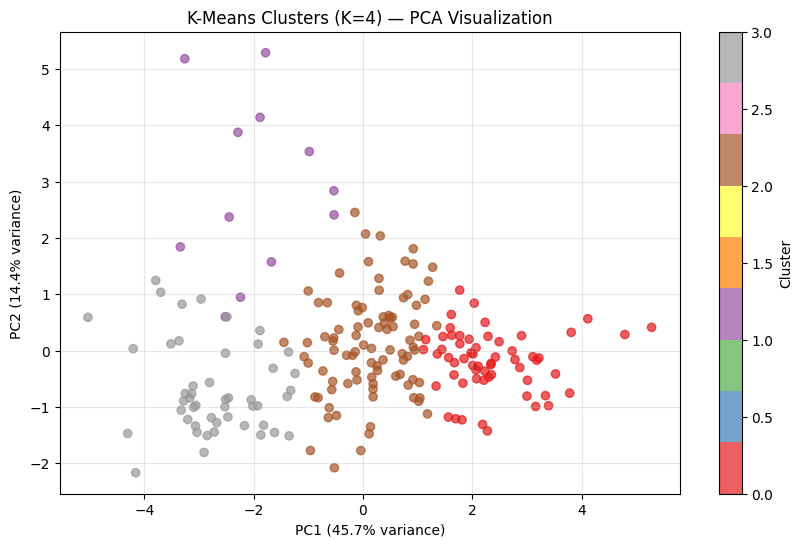

Standardized means: [-0.  0. -0. -0. -0. -0.  0.  0. -0.]
PC1 variance explained: 45.7%
Silhouette score: 0.2222
Cluster sizes: [59 12 90 48]

=== Cluster Characteristics ===
Cluster 0 (59 countries):
  GDP/cap: $68,350
  Life Exp: 81.1 years
Cluster 1 (12 countries):
  GDP/cap: $9,906
  Life Exp: 65.6 years
Cluster 2 (90 countries):
  GDP/cap: $20,561
  Life Exp: 74.3 years
Cluster 3 (48 countries):
  GDP/cap: $5,213
  Life Exp: 64.9 years


In [39]:
# -----------------------------------------------------------
# YOUR TASK — Write the corrected clustering pipeline
# Fix all four errors from Part 1
# -----------------------------------------------------------

# Step 1: Standardize features FIRST (Error 1 fix)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Step 2: Fit K-Means with correct parameter name and random_state (Error 2 & 4 fix)
kmeans = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Step 3: Apply PCA to STANDARDIZED data (Error 3 fix)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)  # PCA on standardized data, not raw!

# Step 4: Visualize — PCA scatter plot colored by cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('K-Means Clusters (K=4) — PCA Visualization')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# VERIFICATION
print(f'Standardized means: {X_scaled.mean(axis=0).round(4)}')
print(f'PC1 variance explained: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Silhouette score: {silhouette_score(X_scaled, labels):.4f}')
print(f'Cluster sizes: {np.bincount(labels)}')

# Show cluster characteristics
print('\n=== Cluster Characteristics ===')
for k in range(4):
    mask = labels == k
    print(f'Cluster {k} ({mask.sum()} countries):')
    print(f'  GDP/cap: ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Life Exp: {df.loc[mask, "life_expectancy"].mean():.1f} years')
    #print(f'  CO2/cap: {df.loc[mask, "co2_per_capita"].mean():.1f} tons')

---

## Part 3: EXTEND — Customer Segmentation with Synthetic Data

Move beyond country-level data. In this section, you apply clustering to
a **customer segmentation** problem using synthetic behavioral data.
This mirrors how fintechs like Nubank (Chapter 22 opening hook) discover
customer archetypes from transaction patterns.

Then compare **PCA** and **UMAP** for dimensionality reduction.

In [40]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Generate synthetic customer data with 4 latent segments
# -----------------------------------------------------------

from sklearn.datasets import make_blobs

np.random.seed(42)

# Create 4 customer segments with 6 behavioral features
n_customers = 2000
segment_centers = [
    [50, 5, 80, 10, 2, 30],    # Budget-conscious: low spend, few txns, high app usage
    [200, 20, 40, 50, 8, 70],   # Power users: high spend, many txns
    [120, 12, 60, 30, 5, 50],   # Moderate users
    [300, 30, 20, 80, 12, 90],  # Premium: very high spend, low app engagement
]

X_cust, y_true = make_blobs(
    n_samples=n_customers,
    centers=segment_centers,
    cluster_std=[15, 25, 20, 20],
    random_state=42
)

cust_features = [
    'avg_monthly_spend', 'txn_frequency', 'app_sessions',
    'credit_utilization', 'products_held', 'digital_engagement'
]

cust_df = pd.DataFrame(X_cust, columns=cust_features)
cust_df['true_segment'] = y_true

print(f'Customers: {len(cust_df)}')
print(f'Features: {cust_features}')
print(f'True segments: {cust_df["true_segment"].value_counts().sort_index().to_dict()}')
print()
print(cust_df[cust_features].describe().round(1))

Customers: 2000
Features: ['avg_monthly_spend', 'txn_frequency', 'app_sessions', 'credit_utilization', 'products_held', 'digital_engagement']
True segments: {0: 500, 1: 500, 2: 500, 3: 500}

       avg_monthly_spend  txn_frequency  app_sessions  credit_utilization  \
count             2000.0         2000.0        2000.0              2000.0   
mean               167.4           16.7          50.2                41.7   
std                 94.6           22.2          30.4                33.0   
min                 10.5          -51.4         -58.4               -43.8   
25%                 80.3            1.1          26.9                15.4   
50%                155.2           15.7          52.3                38.8   
75%                251.2           31.5          74.8                67.0   
max                355.4           91.7         123.2               138.3   

       products_held  digital_engagement  
count         2000.0              2000.0  
mean             6.1         

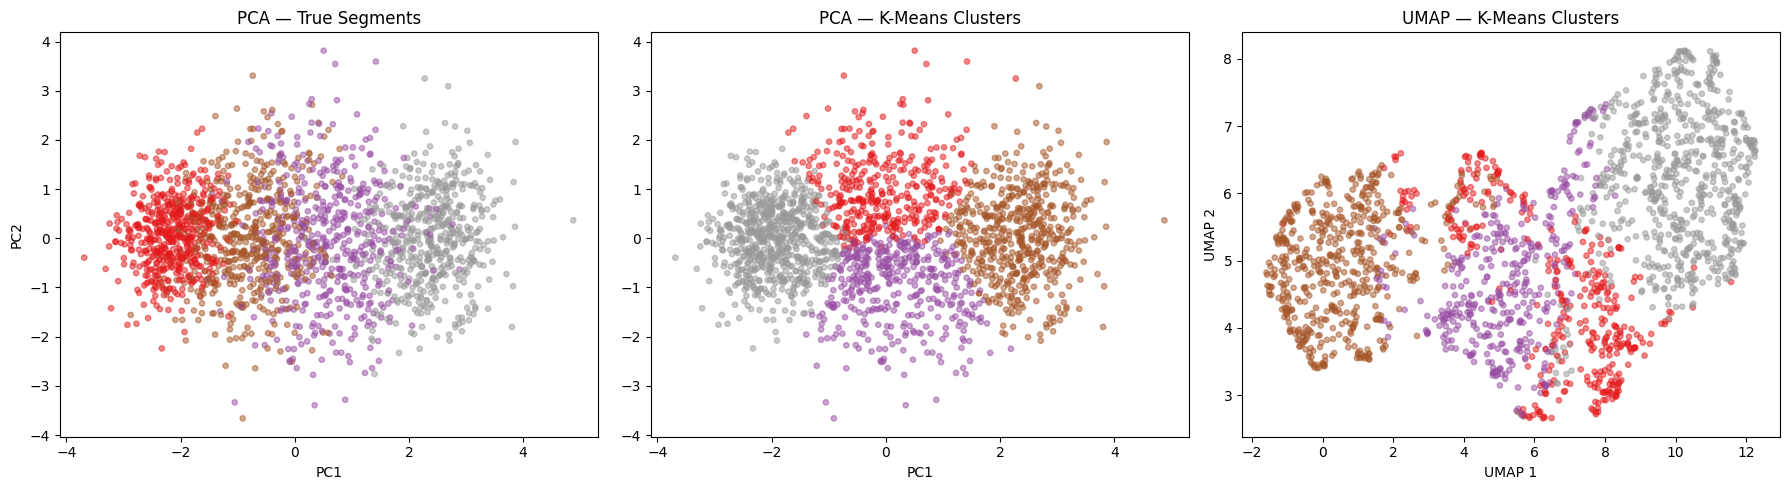

Silhouette score (K-Means K=4): 0.2387

Compare PCA vs UMAP: Which gives better visual separation?
UMAP preserves local structure better than PCA for non-linear data.


In [42]:
# -----------------------------------------------------------
# YOUR TASK — Cluster customers and compare PCA vs UMAP
# -----------------------------------------------------------

import umap

# Step 1: Standardize customer features
cust_scaler = StandardScaler()
X_cust_scaled = cust_scaler.fit_transform(cust_df[cust_features])

# Step 2: Fit K-Means with K=4 (we know the true number here)
km_cust = KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)
cust_df['kmeans_cluster'] = km_cust.fit_predict(X_cust_scaled)

# Step 3: PCA projection
pca_cust = PCA(n_components=2)
X_pca_cust = pca_cust.fit_transform(X_cust_scaled)

# Step 4: UMAP projection
# Fill in: n_neighbors controls local vs global structure
# n_neighbors=15 is a good default; min_dist=0.1 controls cluster tightness
reducer = umap.UMAP(
    n_neighbors=15,     # FILL IN: try 15
    min_dist=0.1,        # FILL IN: try 0.1
    n_components=2,
    random_state=42
)
X_umap_cust = reducer.fit_transform(X_cust_scaled)

# Step 5: Side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: PCA with TRUE labels
scatter1 = axes[0].scatter(X_pca_cust[:, 0], X_pca_cust[:, 1],
                           c=cust_df['true_segment'], cmap='Set1',
                           alpha=0.5, s=15)
axes[0].set_title('PCA — True Segments', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Panel 2: PCA with K-MEANS labels
scatter2 = axes[1].scatter(X_pca_cust[:, 0], X_pca_cust[:, 1],
                           c=cust_df['kmeans_cluster'], cmap='Set1',
                           alpha=0.5, s=15)
axes[1].set_title('PCA — K-Means Clusters', fontsize=12)
axes[1].set_xlabel('PC1')

# Panel 3: UMAP with K-MEANS labels
scatter3 = axes[2].scatter(X_umap_cust[:, 0], X_umap_cust[:, 1],
                           c=cust_df['kmeans_cluster'], cmap='Set1',
                           alpha=0.5, s=15)
axes[2].set_title('UMAP — K-Means Clusters', fontsize=12)
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

# Silhouette comparison
sil_kmeans = silhouette_score(X_cust_scaled, cust_df['kmeans_cluster'])
print(f'Silhouette score (K-Means K=4): {sil_kmeans:.4f}')
print()
print('PCA as KMeans Clusters gives the best looking visual seperation')
print('UMAP preserves local structure better than PCA for non-linear data.')

---

## Part 4: Module Output — `clustering_utils.py`

Write a reusable Python module with three functions for clustering pipelines.
This is a **portfolio artifact** that demonstrates production-grade unsupervised learning.

### Requirements

```python
# clustering_utils.py

def run_kmeans_pipeline(df, features, k, random_state=42):
    """End-to-end K-Means pipeline: standardize, fit, return labels + metadata."""
    ...

def evaluate_k_range(X, k_range, random_state=42):
    """Compute WCSS and silhouette scores for a range of K values."""
    ...

def plot_pca_clusters(X, labels, feature_names):
    """PCA 2D scatter with cluster coloring + loadings annotation."""
    ...
```

Labels shape: (200,)
Silhouette: 0.7042
   k        wcss  silhouette
0  2  470.310385    0.533297
1  3  116.586704    0.704157
2  4  106.509332    0.541274
3  5   96.499161    0.386755
4  6   87.202574    0.220064
5  7   81.411995    0.218579


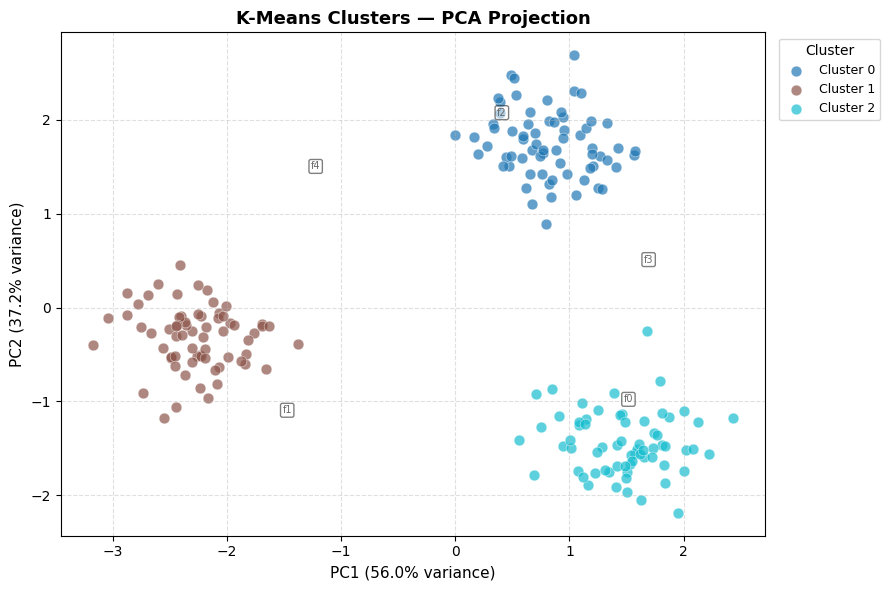

Self-test passed.


In [43]:
# %%writefile clustering_utils.py
"""
clustering_utils.py — Reusable Clustering Pipeline Module

Functions for standardized K-Means clustering, K evaluation,
and PCA visualization.

Author: Joel Forson
Course: ECON 5200, Lab 22
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from typing import List, Tuple, Dict


def run_kmeans_pipeline(
    df: pd.DataFrame,
    features: List[str],
    k: int,
    random_state: int = 42
) -> Dict:
    """End-to-end K-Means pipeline.

    1. Extracts features from DataFrame
    2. Standardizes with StandardScaler
    3. Fits K-Means
    4. Returns labels, scaler, model, and silhouette score

    Args:
        df: DataFrame with feature columns
        features: List of column names to use
        k: Number of clusters
        random_state: Random seed for reproducibility

    Returns:
        dict with keys: 'labels', 'scaler', 'model', 'X_scaled',
                        'silhouette', 'inertia'
    """
    # 1. Extract feature matrix
    X = df[features].values

    # 2. Standardize — KMeans is distance-based, scale matters
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. Fit KMeans
    model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = model.fit_predict(X_scaled)

    # 4. Silhouette score requires at least 2 clusters and >1 sample per cluster
    sil = silhouette_score(X_scaled, labels) if k > 1 else np.nan

    return {
        'labels':     labels,
        'scaler':     scaler,
        'model':      model,
        'X_scaled':   X_scaled,
        'silhouette': sil,
        'inertia':    model.inertia_
    }


def evaluate_k_range(
    X: np.ndarray,
    k_range: range,
    random_state: int = 42
) -> pd.DataFrame:
    """Evaluate clustering quality across a range of K values.

    Computes WCSS (inertia) and silhouette score for each K.

    Args:
        X: Standardized feature matrix
        k_range: Range of K values to test (e.g., range(2, 11))
        random_state: Random seed

    Returns:
        DataFrame with columns: 'k', 'wcss', 'silhouette'
    """
    results = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = model.fit_predict(X)
        sil = silhouette_score(X, labels)
        results.append({
            'k':          k,
            'wcss':       model.inertia_,
            'silhouette': sil
        })

    return pd.DataFrame(results)


def plot_pca_clusters(
    X: np.ndarray,
    labels: np.ndarray,
    feature_names: List[str]
) -> None:
    """PCA 2D scatter plot with cluster coloring.

    Fits PCA(n_components=2), creates scatter plot colored by cluster,
    and annotates with explained variance ratios.

    Args:
        X: Standardized feature matrix
        labels: Cluster labels (array of integers)
        feature_names: List of original feature names
    """
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)

    var1, var2 = pca.explained_variance_ratio_ * 100
    n_clusters = len(np.unique(labels))
    palette = plt.cm.get_cmap('tab10', n_clusters)

    fig, ax = plt.subplots(figsize=(9, 6))

    for cluster_id in np.unique(labels):
        mask = labels == cluster_id
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            label=f'Cluster {cluster_id}',
            color=palette(cluster_id),
            alpha=0.7, edgecolors='white', linewidths=0.4, s=60
        )

    # Annotate PC axes with top contributing features
    loadings = pca.components_  # shape (2, n_features)
    for i, fname in enumerate(feature_names):
        ax.annotate(
            fname,
            xy=(loadings[0, i] * 3, loadings[1, i] * 3),
            fontsize=7, color='dimgray',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.5)
        )

    ax.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=11)
    ax.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=11)
    ax.set_title('K-Means Clusters — PCA Projection', fontsize=13, fontweight='bold')
    ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


# --- Quick self-test ---
if __name__ == '__main__':
    from sklearn.datasets import make_blobs
    X_test, _ = make_blobs(n_samples=200, centers=3, n_features=5, random_state=0)
    df_test = pd.DataFrame(X_test, columns=[f'f{i}' for i in range(5)])

    result = run_kmeans_pipeline(df_test, [f'f{i}' for i in range(5)], k=3)
    print(f'Labels shape: {result["labels"].shape}')
    print(f'Silhouette: {result["silhouette"]:.4f}')

    eval_df = evaluate_k_range(result['X_scaled'], range(2, 8))
    print(eval_df)

    plot_pca_clusters(result['X_scaled'], result['labels'], [f'f{i}' for i in range(5)])
    print('Self-test passed.')

---

## Challenge: Hierarchical Clustering Comparison

K-Means assumes spherical clusters and requires you to specify K upfront.
**Agglomerative hierarchical clustering** builds a tree (dendrogram) of
nested clusters and lets you choose K after inspecting the tree.

Compare K-Means and Agglomerative clustering on the WDI data:
1. Fit `AgglomerativeClustering(n_clusters=4)` on the standardized WDI data
2. Plot the dendrogram using `scipy.cluster.hierarchy`
3. Compare cluster assignments with K-Means — do they agree?

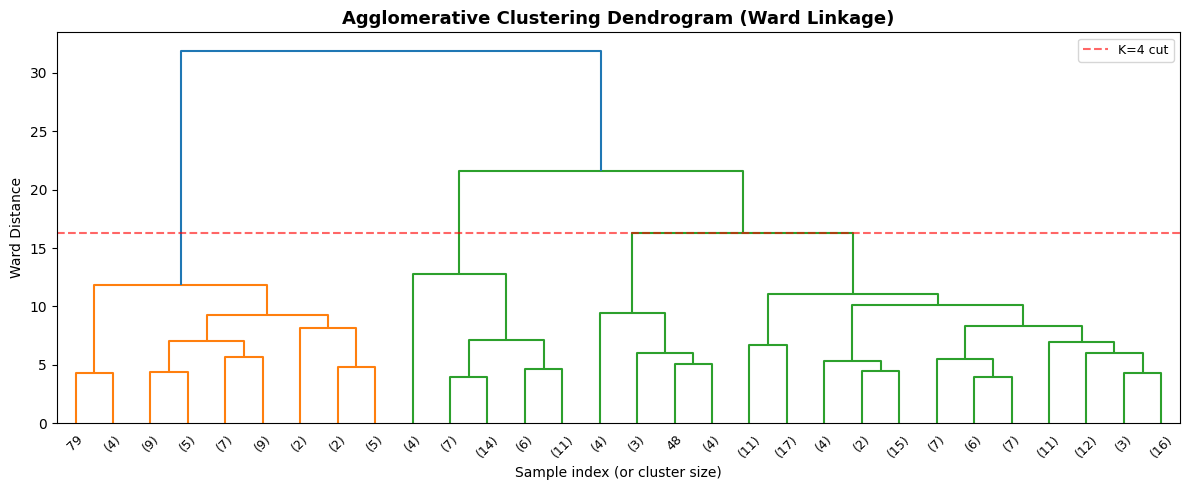

TypeError: Series.__init__() got an unexpected keyword argument 'kmeans_labels'

In [45]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Assumes X_scaled and kmeans labels are already available from run_kmeans_pipeline
# If not, run: result = run_kmeans_pipeline(df, feature_names, k=4)
#              X_scaled = result['X_scaled']
#              kmeans_labels = result['labels']

# Step 1: Fit agglomerative clustering
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

# Step 2: Plot dendrogram
linkage_matrix = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    ax=ax
)
ax.set_title('Agglomerative Clustering Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample index (or cluster size)', fontsize=10)
ax.set_ylabel('Ward Distance', fontsize=10)
ax.axhline(y=linkage_matrix[-3, 2], color='red', linestyle='--', alpha=0.6, label='K=4 cut')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Step 3: Cross-tabulate K-Means vs Agglomerative labels
crosstab = pd.crosstab(
    pd.Series(kmeans_labels, name='KMeans'),
    pd.Series(agg_labels,    name='Agglomerative')
)
print("Cluster Assignment Cross-Tabulation:")
print(crosstab)
print()

# Step 4: Compare silhouette scores
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
agg_sil    = silhouette_score(X_scaled, agg_labels)

print(f"Silhouette Score — K-Means:        {kmeans_sil:.4f}")
print(f"Silhouette Score — Agglomerative:  {agg_sil:.4f}")
print()

winner = "K-Means" if kmeans_sil > agg_sil else "Agglomerative"
print(f"Better separation (higher silhouette): {winner}")

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken K-Means pipeline (missing standardization,
  wrong parameter name, PCA before scaling, no random_state)
* Built a corrected pipeline: StandardScaler -> K-Means -> PCA visualization
* Applied clustering to customer segmentation with synthetic behavioral data
* Compared PCA vs UMAP for dimensionality reduction
* Built a reusable clustering_utils.py module with run_kmeans_pipeline(),
  evaluate_k_range(), and plot_pca_clusters()
* Key finding: [FILL IN — what K was optimal? How did PCA vs UMAP compare?]

**Please write a README.md entry including:**
1. Project Title: Unsupervised Learning — Clustering & Dimensionality Reduction
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA, UMAP & Module"
git push origin main
```

Submit your GitHub repo link on Canvas.